In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [76]:
df = pd.read_csv("C:/Machine Learning/DataSets/dirty_cafe_sales.csv")


In [77]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [78]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [79]:
df.size

80000

In [80]:
df.shape

(10000, 8)

In [81]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [83]:
 df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [84]:
 def outliers_identify(df,column):
     col = df[column]
     q1 = col.quantile(0.25)
     q3 = col.quantile(0.75)
     IQR = q3 - q1
     lower_bound = q1 - (1.5 * IQR)
     upper_bound = q3 + (1.5 * IQR)
     outliers = df[(col < lower_bound) | (col > upper_bound)]
     print(f"{column} -> Outliers :",outliers.shape[0])
     return 

In [85]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [86]:
df["Quantity"].unique()
 


array(['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan], dtype=object)

In [87]:
df["Price Per Unit"].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN'],
      dtype=object)

In [88]:
df["Total Spent"].unique()

array(['4.0', '12.0', 'ERROR', '10.0', '20.0', '9.0', '16.0', '15.0',
       '25.0', '8.0', '5.0', '3.0', '6.0', nan, 'UNKNOWN', '2.0', '1.0',
       '7.5', '4.5', '1.5'], dtype=object)

In [89]:
df["Transaction Date"].unique()

array(['2023-09-08', '2023-05-16', '2023-07-19', '2023-04-27',
       '2023-06-11', '2023-03-31', '2023-10-06', '2023-10-28',
       '2023-07-28', '2023-12-31', '2023-11-07', 'ERROR', '2023-05-03',
       '2023-06-01', '2023-03-21', '2023-11-15', '2023-06-10',
       '2023-02-24', '2023-03-25', '2023-01-15', '2023-04-04',
       '2023-03-30', '2023-12-01', '2023-09-18', '2023-06-03',
       '2023-12-13', '2023-04-20', '2023-04-10', '2023-03-11',
       '2023-06-02', '2023-11-06', '2023-08-15', '2023-10-09',
       '2023-05-28', '2023-07-17', '2023-04-29', '2023-06-08',
       '2023-06-29', '2023-04-17', '2023-12-22', '2023-01-10',
       '2023-10-02', '2023-02-23', '2023-03-22', '2023-11-03',
       '2023-03-02', '2023-06-26', '2023-05-02', '2023-09-05',
       '2023-01-08', '2023-03-15', '2023-11-25', '2023-12-05',
       '2023-03-19', '2023-06-27', '2023-04-19', '2023-10-07',
       '2023-09-30', '2023-05-27', '2023-11-18', '2023-10-20',
       '2023-10-03', '2023-10-27', '2023-04-06

In [90]:
cols = ["Quantity", "Price Per Unit", "Total Spent", "Transaction Date"]

df[cols] = df[cols].replace(["ERROR", "UNKNOWN"], np.nan)

In [91]:
(df[cols] == "ERROR").sum().sum()

np.int64(0)

In [92]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9521 non-null   object
 3   Price Per Unit    9467 non-null   object
 4   Total Spent       9498 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9540 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [94]:
df["Quantity"] = pd.to_numeric(df["Quantity"])
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"])
df["Total Spent"] = pd.to_numeric(df["Total Spent"])
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              9667 non-null   object        
 2   Quantity          9521 non-null   float64       
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    7421 non-null   object        
 6   Location          6735 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


In [96]:
df = df.dropna(subset = ["Item"]).reset_index(drop = True)
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9662,TXN_7851634,UNKNOWN,4.0,4.0,16.0,NaN,NaN,2023-01-08
9663,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9664,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9665,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [97]:
df["Price Per Unit"] = df.groupby("Item")["Price Per Unit"].transform(lambda x: x.fillna(x.median()))

In [98]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

In [99]:
df["Payment Method"] = df["Payment Method"].fillna("Unknown")
df["Location"] = df["Location"].fillna("Unknown")

In [100]:
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]

In [101]:
df.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    442
dtype: int64

In [102]:
df['Transaction Date'].isna().mean()

np.float64(0.04572256129098996)

In [103]:
df = df.dropna(subset = ["Transaction Date"]).reset_index(drop = True)

In [104]:
df["Location"].unique()
 

array(['Takeaway', 'In-store', 'UNKNOWN', 'Unknown', 'ERROR'],
      dtype=object)

In [105]:
df["Payment Method"] = df["Payment Method"].str.lower()

In [106]:
df["Location"] = df["Location"].str.strip().str.lower()

In [107]:
df["Payment Method"] = df["Payment Method"].replace(["unknown","error"],"unknown")

In [108]:
df["Location"] = df["Location"].replace(["unknown","error"],"unknown")
df["Item"] = df["Item"].str.lower().replace(["unknown","error"],"unknown")

In [109]:
df["Payment Method"].unique()
 

array(['credit card', 'cash', 'unknown', 'digital wallet'], dtype=object)

In [110]:
df["Location"].unique()

array(['takeaway', 'in-store', 'unknown'], dtype=object)

In [111]:
df["Day"] = df["Transaction Date"].dt.day_name()
df["Month"] = df["Transaction Date"].dt.month
df["Is_Weekend"] = df["Transaction Date"].dt.weekday >= 5

In [112]:
df


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day,Month,Is_Weekend
0,TXN_1961373,coffee,2.0,2.0,4.0,credit card,takeaway,2023-09-08,Friday,9,False
1,TXN_4977031,cake,4.0,3.0,12.0,cash,in-store,2023-05-16,Tuesday,5,False
2,TXN_4271903,cookie,4.0,1.0,4.0,credit card,in-store,2023-07-19,Wednesday,7,False
3,TXN_7034554,salad,2.0,5.0,10.0,unknown,unknown,2023-04-27,Thursday,4,False
4,TXN_3160411,coffee,2.0,2.0,4.0,digital wallet,in-store,2023-06-11,Sunday,6,True
...,...,...,...,...,...,...,...,...,...,...,...
9220,TXN_7851634,unknown,4.0,4.0,16.0,unknown,unknown,2023-01-08,Sunday,1,True
9221,TXN_7672686,coffee,2.0,2.0,4.0,unknown,unknown,2023-08-30,Wednesday,8,False
9222,TXN_5255387,coffee,4.0,2.0,8.0,digital wallet,unknown,2023-03-02,Thursday,3,False
9223,TXN_7695629,cookie,3.0,1.0,3.0,digital wallet,unknown,2023-12-02,Saturday,12,True


In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df = df.drop_duplicates()


In [115]:
df.head()
 

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day,Month,Is_Weekend
0,TXN_1961373,coffee,2.0,2.0,4.0,credit card,takeaway,2023-09-08,Friday,9,False
1,TXN_4977031,cake,4.0,3.0,12.0,cash,in-store,2023-05-16,Tuesday,5,False
2,TXN_4271903,cookie,4.0,1.0,4.0,credit card,in-store,2023-07-19,Wednesday,7,False
3,TXN_7034554,salad,2.0,5.0,10.0,unknown,unknown,2023-04-27,Thursday,4,False
4,TXN_3160411,coffee,2.0,2.0,4.0,digital wallet,in-store,2023-06-11,Sunday,6,True


In [116]:
def outliers_check(df,column):
   cols = df[column]
   q1 = cols.quantile(0.25)
   q3 = cols.quantile(0.75)
   IQR = q3 - q1 
   lower = q1 - (1.5 * IQR)
   upper = q3 + (1.5 * IQR)
   outliers = df[(cols < lower) | (cols > upper)]
   return outliers

In [117]:
out = outliers_check(df,"Total Spent")
print(out)

     Transaction ID     Item  Quantity  Price Per Unit  Total Spent  \
9       TXN_2548360    salad       5.0             5.0         25.0   
46      TXN_6342161    salad       5.0             5.0         25.0   
47      TXN_8914892  unknown       5.0             5.0         25.0   
87      TXN_5220895    salad       5.0             5.0         25.0   
136     TXN_8687151    salad       5.0             5.0         25.0   
...             ...      ...       ...             ...          ...   
9032    TXN_1232346    salad       5.0             5.0         25.0   
9046    TXN_9506076    salad       5.0             5.0         25.0   
9113    TXN_6393305    salad       5.0             5.0         25.0   
9140    TXN_8922585    salad       5.0             5.0         25.0   
9199    TXN_6120851    salad       5.0             5.0         25.0   

      Payment Method  Location Transaction Date        Day  Month  Is_Weekend  
9               cash  takeaway       2023-11-07    Tuesday     11  

In [118]:
outliers2 = outliers_check(df,"Price Per Unit")
outliers2.shape

(0, 11)

In [119]:
df = df.drop(columns = ["Transaction ID" , "Transaction Date"])

In [120]:
X = df.drop(columns = ["Total Spent"])

In [121]:
Y = df["Total Spent"]

In [122]:
df.index

RangeIndex(start=0, stop=9225, step=1)

In [123]:
df["Total Spent"].describe()

count    9225.000000
mean        8.922493
std         5.920802
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        25.000000
Name: Total Spent, dtype: float64

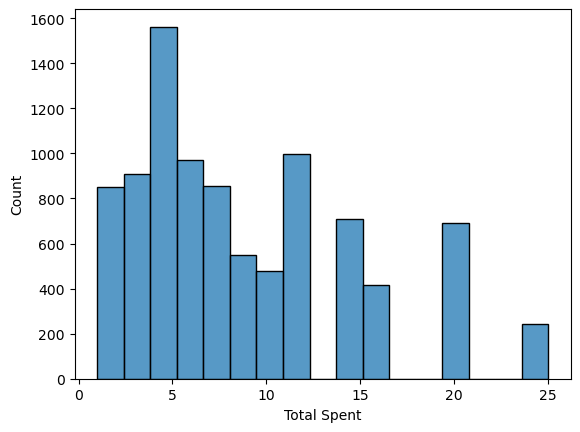

In [124]:
sns.histplot(df["Total Spent"],bins = 17)

plt.show()

In [125]:
print(df["Total Spent"].skew())

0.8285151462378246


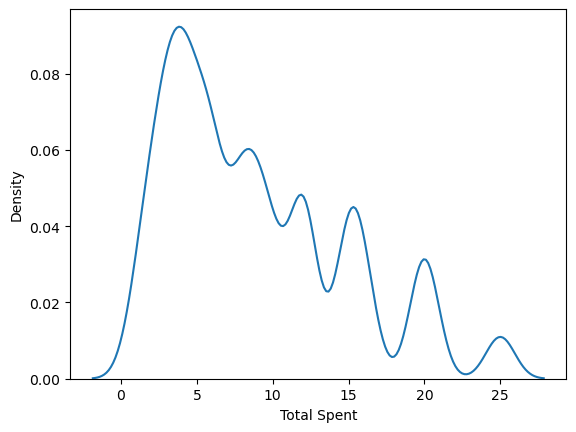

In [126]:
sns.kdeplot(df["Total Spent"])
plt.show()

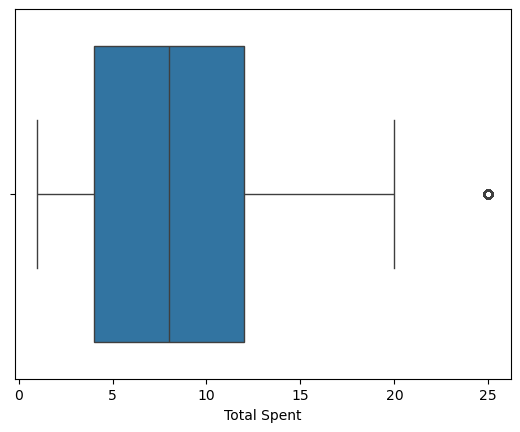

In [127]:
sns.boxplot(x=df["Total Spent"])
plt.show()

In [128]:
df["Total Spent"].value_counts()

Total Spent
12.0    995
6.0     969
3.0     910
4.0     852
15.0    709
20.0    692
8.0     630
9.0     547
10.0    480
2.0     459
5.0     442
16.0    414
4.5     268
25.0    242
7.5     225
1.0     204
1.5     187
Name: count, dtype: int64

In [129]:
df[df['Total Spent'] == 4.0]

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Day,Month,Is_Weekend
0,coffee,2.0,2.0,4.0,credit card,takeaway,Friday,9,False
2,cookie,4.0,1.0,4.0,credit card,in-store,Wednesday,7,False
4,coffee,2.0,2.0,4.0,digital wallet,in-store,Sunday,6,True
14,sandwich,1.0,4.0,4.0,unknown,unknown,Saturday,6,True
30,sandwich,1.0,4.0,4.0,credit card,unknown,Sunday,5,True
...,...,...,...,...,...,...,...,...,...
9179,unknown,4.0,1.0,4.0,unknown,takeaway,Friday,10,False
9180,sandwich,1.0,4.0,4.0,digital wallet,unknown,Saturday,1,True
9194,coffee,2.0,2.0,4.0,unknown,unknown,Wednesday,5,False
9197,coffee,2.0,2.0,4.0,cash,in-store,Tuesday,9,False


In [130]:
df["Item"].value_counts()

Item
juice       1124
coffee      1123
salad       1099
cake        1082
sandwich    1075
smoothie    1048
cookie      1035
tea         1027
unknown      612
Name: count, dtype: int64

<Axes: xlabel='Item', ylabel='Count'>

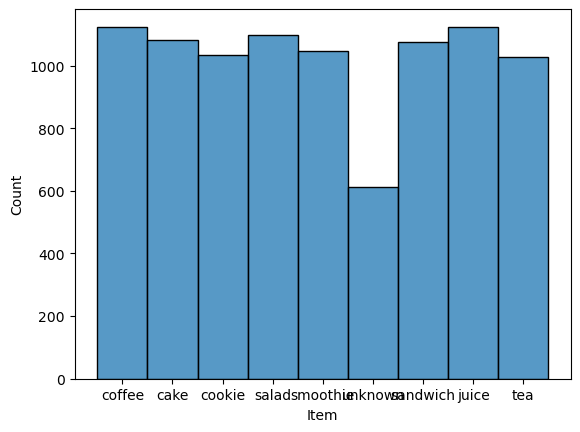

In [131]:
sns.histplot(df["Item"])

#Bivariate Analysis 

In [132]:
df.groupby("Item")["Total Spent"].mean()

Item
cake         9.088725
coffee       6.099733
cookie       2.988406
juice        8.943950
salad       15.077343
sandwich    12.152558
smoothie    12.244275
tea          4.564265
unknown      8.703431
Name: Total Spent, dtype: float64

In [133]:
df.groupby("Item")["Total Spent"].sum()

Item
cake         9834.0
coffee       6850.0
cookie       3093.0
juice       10053.0
salad       16570.0
sandwich    13064.0
smoothie    12832.0
tea          4687.5
unknown      5326.5
Name: Total Spent, dtype: float64

In [134]:
df[["Price Per Unit" ,"Item","Quantity"]].value_counts()

Price Per Unit  Item      Quantity
3.0             juice     3.0         271
4.0             sandwich  3.0         270
2.0             coffee    3.0         267
1.5             tea       3.0         246
4.0             smoothie  3.0         240
                                     ... 
2.0             unknown   1.0          12
1.0             unknown   5.0          11
5.0             unknown   3.0          11
2.0             unknown   5.0          10
1.5             unknown   4.0           9
Name: count, Length: 70, dtype: int64

In [135]:
df["Item"].unique()

array(['coffee', 'cake', 'cookie', 'salad', 'smoothie', 'unknown',
       'sandwich', 'juice', 'tea'], dtype=object)

In [136]:
pd.crosstab(
    df["Item"],
    df["Price Per Unit"]
)

Price Per Unit,1.0,1.5,2.0,3.0,4.0,5.0
Item,,,,,,
cake,0,0,0,1082,0,0
coffee,0,0,1123,0,0,0
cookie,1035,0,0,0,0,0
juice,0,0,0,1124,0,0
salad,0,0,0,0,0,1099
sandwich,0,0,0,0,1075,0
smoothie,0,0,0,0,1048,0
tea,0,1027,0,0,0,0
unknown,76,76,78,178,125,79


In [137]:
df.loc[((df["Item"] == "unknown") & (df["Price Per Unit"] == 1.0)) ,"Item"] = "cookie"
df.loc[((df["Item"] == "unknown") & (df["Price Per Unit"] == 2.0)) ,"Item"] = "coffee"
df.loc[((df["Item"] == "unknown") & (df["Price Per Unit"] == 1.5)) ,"Item"] = "tea"
df.loc[((df["Item"] == "unknown") & (df["Price Per Unit"] == 5.0)) ,"Item"] = "salad"
df["Item"].value_counts()

Item
coffee      1201
salad       1178
juice       1124
cookie      1111
tea         1103
cake        1082
sandwich    1075
smoothie    1048
unknown      303
Name: count, dtype: int64

<Axes: xlabel='Quantity', ylabel='Total Spent'>

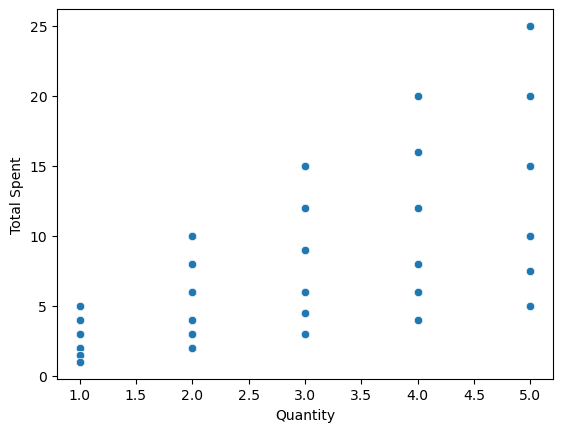

In [139]:
sns.scatterplot(x = "Quantity" , y = "Total Spent",data = df)

In [144]:
pd.crosstab( df["Item"] , df["Payment Method"])

Payment Method,cash,credit card,digital wallet,unknown
Item,,,,
cake,264,240,239,339
coffee,245,253,273,430
cookie,251,259,263,338
juice,258,264,279,323
salad,294,286,252,346
sandwich,241,242,242,350
smoothie,223,243,244,338
tea,248,240,256,359
unknown,63,66,72,102


In [145]:
pd.crosstab( df["Item"] , df["Location"])

Location,in-store,takeaway,unknown
Item,,,
cake,305,329,448
coffee,326,366,509
cookie,335,375,401
juice,348,321,455
salad,373,359,446
sandwich,355,323,397
smoothie,305,293,450
tea,332,337,434
unknown,90,86,127


In [148]:
df.groupby("Item")["Total Spent"].mean()

Item
cake         9.088725
coffee       6.074938
cookie       2.989199
juice        8.943950
salad       15.021222
sandwich    12.152558
smoothie    12.244275
tea          4.547597
unknown     10.557756
Name: Total Spent, dtype: float64

In [151]:
df.groupby("Item")["Quantity"].mean()

Item
cake        3.029575
coffee      3.037469
cookie      2.989199
juice       2.981317
salad       3.004244
sandwich    3.038140
smoothie    3.061069
tea         3.031732
unknown     3.085809
Name: Quantity, dtype: float64

In [153]:
df["Quantity"].corr(df["Total Spent"])

np.float64(0.6974572927138701)

In [154]:
df["Price Per Unit"].corr(df["Total Spent"])

np.float64(0.653752017859136)

In [158]:
df[["Quantity","Price Per Unit","Total Spent"]].corr()

,Quantity,Price Per Unit,Total Spent
Quantity,1.000000,0.004379,0.697457
Price Per Unit,0.004379,1.000000,0.653752
Total Spent,0.697457,0.653752,1.000000


<Axes: xlabel='Price Per Unit', ylabel='Total Spent'>

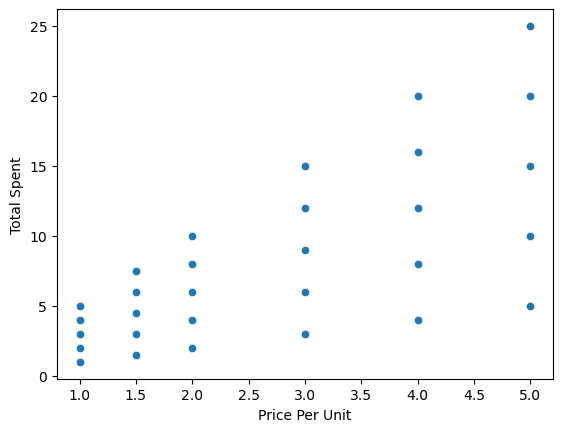

In [159]:
sns.scatterplot( x = "Price Per Unit", y = "Total Spent" , data = df)

In [160]:
df


,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Day,Month,Is_Weekend
0,coffee,2.0,2.0,4.0,credit card,takeaway,Friday,9,False
1,cake,4.0,3.0,12.0,cash,in-store,Tuesday,5,False
2,cookie,4.0,1.0,4.0,credit card,in-store,Wednesday,7,False
3,salad,2.0,5.0,10.0,unknown,unknown,Thursday,4,False
4,coffee,2.0,2.0,4.0,digital wallet,in-store,Sunday,6,True
...,...,...,...,...,...,...,...,...,...
9220,unknown,4.0,4.0,16.0,unknown,unknown,Sunday,1,True
9221,coffee,2.0,2.0,4.0,unknown,unknown,Wednesday,8,False
9222,coffee,4.0,2.0,8.0,digital wallet,unknown,Thursday,3,False
9223,cookie,3.0,1.0,3.0,digital wallet,unknown,Saturday,12,True


In [161]:
df.columns

Index(['Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method',
       'Location', 'Day', 'Month', 'Is_Weekend'],
      dtype='object')

In [168]:
pd.crosstab(df["Month"],df["Item"])

Item,cake,coffee,cookie,juice,salad,sandwich,smoothie,tea,unknown
Month,,,,,,,,,
1,95,94,91,100,111,112,70,98,24
2,75,90,79,94,95,74,80,91,27
3,101,108,100,105,99,92,82,88,25
4,87,94,79,96,105,85,93,85,22
5,85,94,92,96,94,98,89,82,24
6,84,109,92,94,104,94,91,92,25
7,85,99,105,75,104,96,89,92,22
8,87,102,85,78,102,95,81,108,34
9,101,87,97,87,80,89,93,100,28


In [169]:
df.groupby("Is_Weekend")["Total Spent"].mean()

Is_Weekend
False    8.911966
True     8.948640
Name: Total Spent, dtype: float64